In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Flatten 
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU, Dropout
from  tensorflow.keras.optimizers  import  Adam
import numpy as np
import matplotlib.pyplot as plt


In [4]:
(x_train, _), (_, _) = mnist.load_data()
# Normalize images to [-1, 1]
x_train = (x_train.astype('float32') - 127.5) / 127.5
# Reshape to (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
print("Training data shape:", x_train.shape)


Training data shape: (60000, 28, 28, 1)


In [8]:
def build_generator():
    model = Sequential()
    model.add(Dense(7*7*128, input_dim=100))
    model.add(LeakyReLU(0.2)) 
    model.add(Reshape((7, 7, 128)))
    model.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Conv2DTranspose(1, kernel_size=4, strides=2, padding='same',activation='tanh'))
    return model
generator = build_generator() 
generator.summary()



D:\user\envs\tanubhalerao\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 765,633 (2.92 MB)

 Trainable params: 765,633 (2.92 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def build_discriminator():
    model = Sequential()
    model.add(Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=(28,28,1)))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))
    model.add(Conv2D(128, kernel_size=4, strides=2, padding='same')) 
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    return model
discriminator = build_discriminator() 
discriminator.summary()



D:\user\envs\tanubhalerao\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
discriminator.compile( loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy']
)


In [13]:
discriminator.trainable = False
gan = Sequential() 
gan.add(generator)
gan.add(discriminator)
gan.compile(
loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5)
)


In [15]:
def train_dcgan(epochs=3000, batch_size=64, sample_interval=500): 
    real = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))
    for epoch in range(epochs):
    # Train Discriminator
        idx = np.random.randint(0, x_train.shape[0], batch_size)
        real_imgs = x_train[idx]
        noise = np.random.normal(0, 1, (batch_size, 100)) 
        fake_imgs = generator.predict(noise, verbose=0)
        d_loss_real = discriminator.train_on_batch(real_imgs, real)
        d_loss_fake = discriminator.train_on_batch(fake_imgs, fake)
        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, 100))
        g_loss = gan.train_on_batch(noise, real)
        if epoch % sample_interval == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss_real[0]:.4f} | G Loss:{g_loss:.4f}")
            sample_images(epoch)


In [16]:
def sample_images(epoch):
    noise = np.random.normal(0, 1, (16, 100))
    gen_imgs = generator.predict(noise, verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5	# Rescale to [0,1]
    fig, axs = plt.subplots(4, 4, figsize=(4,4))
    count = 0
    for i in range(4):
        for j in range(4):
            axs[i,j].imshow(gen_imgs[count, :, :, 0], cmap='gray') 
            axs[i,j].axis('off')
            count += 1
    plt.suptitle(f"Generated Images at Epoch {epoch}") 
    plt.show()


D:\user\envs\tanubhalerao\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.7287 | G Loss:0.6942


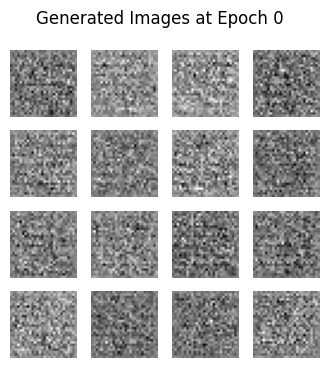

Epoch 500 | D Loss: 0.9924 | G Loss:0.3735


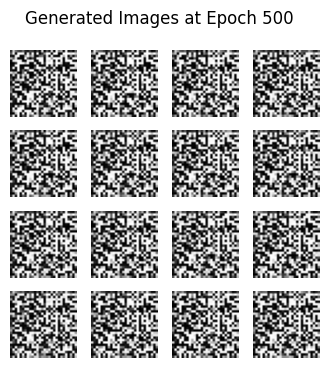

Epoch 1000 | D Loss: 1.1190 | G Loss:0.2821


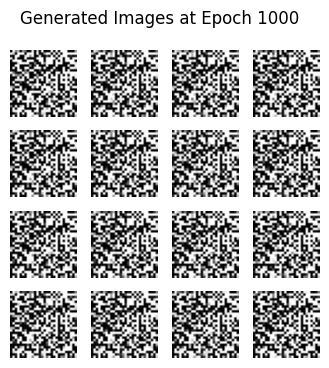

Epoch 1500 | D Loss: 1.1717 | G Loss:0.2473


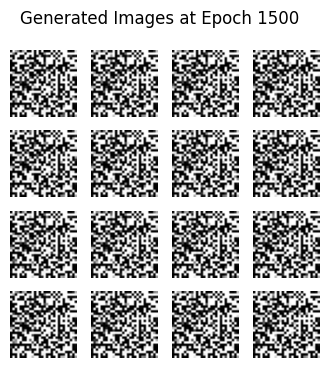

Epoch 2000 | D Loss: 1.2004 | G Loss:0.2290


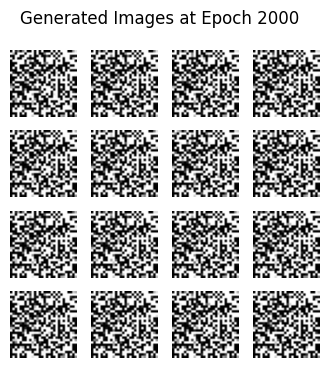

Epoch 2500 | D Loss: 1.2184 | G Loss:0.2177


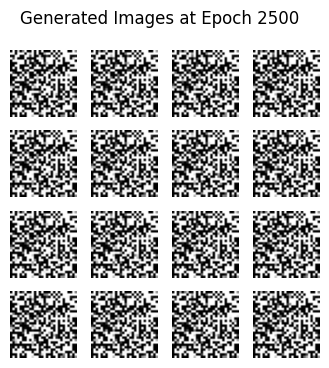

In [17]:
 train_dcgan(epochs=3000, batch_size=64, sample_interval=500)	